In [1]:
import numpy as np
from itertools import chain

from response_stats.generators import PoissonSpikeGenerator
from response_stats.responses import ResponseConfig, make_response_data, ResponseDetector
from response_stats.responses.response_tests import WilcoxonTest, SurrogateTest

from response_stats.plot_utils import *

TestKind.PARAMETRIC
parametric


(<Figure size 600x400 with 4 Axes>,
 {'raster': <Axes: label='raster'>,
  'isi': <Axes: label='isi', xlabel='ISI [s]', ylabel='count'>,
  'text': <Axes: label='text'>,
  'r_t': <Axes: label='r_t', xlabel='time [ms]', ylabel='fr [Hz]'>})

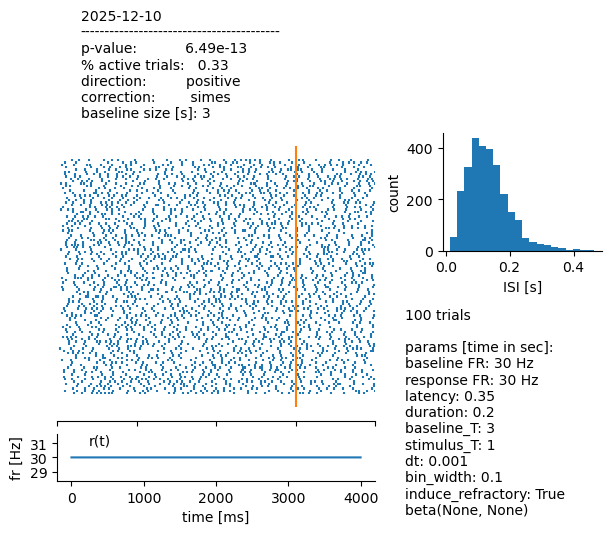

In [2]:
baseline_fr = 30
response_fr = 30
latency = 0.35
duration = 0.2
dt = 0.001
baseline_T = 3
stimulus_T = 1

total_bins = int((baseline_T + stimulus_T) / dt)

induce_refractory_period = True

n_trials = 100

generator = PoissonSpikeGenerator(
    baseline_fr=baseline_fr,
    response_fr=response_fr,
    latency=latency,
    duration=duration,
    baseline_T=baseline_T,
    stimulus_T=stimulus_T,
    dt=dt,
    induce_refractory_period=induce_refractory_period,
    
)

trial_activity = generator.generate(n_trials)

cfg_response_dict = {
    "trial_activity": trial_activity,
    "baseline_T": baseline_T,
    "stimulus_T": stimulus_T,
    "stimulus_onset": 1,
    "bin_width": 0.1,
    "dt": dt,
    "direction": "positive",
    "proportion_active": 1/3,
    "multiple_correction": "simes",
    "interleave_response_bins": True,
    "smooth_response_bins": False,
    "debug": False,
}

cfg_response = ResponseConfig(**cfg_response_dict)
data_response = make_response_data(cfg_response)

detector = ResponseDetector(data_response, WilcoxonTest)

SpikeSummaryFigure(trial_activity, generator, detector, ).build()

In [6]:
from response_stats.responses.response_tests import ResponseTest, TestKind

In [11]:
print(detector.test.kind == TestKind.PARAMETRIC)
print(detector.test.kind )

False
TestKind.PARAMETRIC


In [12]:
print(detector.test.kind.__module__)
print(TestKind.PARAMETRIC.__module__)

responses.response_tests.base
response_stats.responses.response_tests.base


In [49]:
detector.compute_min_pval()

np.float64(6.491006501746455e-13)

np.float64(0.0)

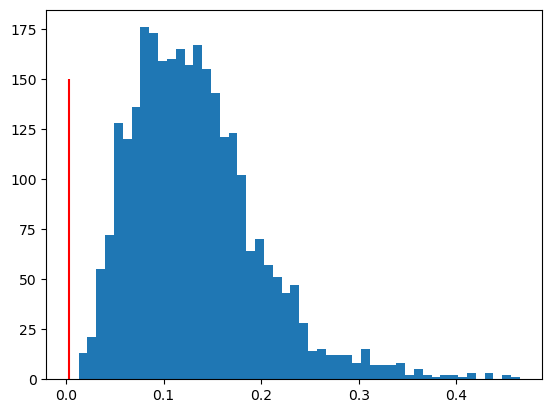

In [57]:
isis = np.array(list(chain.from_iterable([np.diff(t) for t in trial_activity])))
plt.hist(isis, bins=50)
plt.vlines(0.003, ymin=0, ymax=150, colors="red")

sum(isis < 0.003) / len(isis) * 100

In [13]:
bin_width = 0.05

bins = np.arange(0, baseline_T+stimulus_T+bin_width, bin_width)
hist = np.array([np.histogram(trial, bins)[0] for trial in trial_activity])

len(bins)

81

In [16]:
shifts = generator.rng.integers(1, high=hist.shape[1], size=n_trials, dtype=np.int64, )


In [29]:
hist = np.array([[1,2,3,4,5], 
        [1,2,3,4,5],
        [1,2,3,4,5],
        [1,2,3,4,5],
        [1,2,3,4,5]])

shifts = [1,2,3,4,5]


In [45]:
def _generate_surrogate(trial_activity_hist):
    n_trials = trial_activity_hist.shape[0]
    shifts = generator.rng.integers(1, high=trial_activity_hist.shape[1], size=n_trials, dtype=np.int64, )
    return [np.roll(trial_activity_hist[n], shifts[n]) for n in np.arange(n_trials)]


surrogates = np.zeros((10, hist.shape[0], hist.shape[1]))
for perm in np.arange(10):
    s = _generate_surrogate(hist)
    surrogates[perm, :, :] = s


In [47]:
surrogates.shape

(10, 5, 5)

In [ ]:


def construct_surrogates(self, data: ResponseData) -> np.ndarray:
    trial_activity_hist = self._bin_whole_trials(data)

    surrogates = np.zeros(self.n_perms, trial_activity_hist.shape[0], trial_activity_hist.shape[1])
    for perm in np.arange(self.n_perms):
        s = self._generate_surrogate(trial_activity_hist)
        surrogates[perm, :, :] = s
    return surrogates
